In [21]:
import os
import numpy as np
import numpy.matlib as matlib
import pandas as pd
import scipy.signal
import scipy.stats
import scipy.io.wavfile
import scipy.fftpack

import matplotlib.pyplot as plt

from pynwb import NWBHDF5IO
import MelFilterBank as mel
# pip install pynwb
from lib import plotsEEG, plotRawSpec, plotsEEGFeatures


# Data
* Download from https://osf.io/nrgx6/files/osfstorage
* Description can be found in https://www.nature.com/articles/s41597-022-01542-9
![experiment design](experiment.png)

In [2]:
# Inspect the data
path_bids = r'./SingleWordProductionDutch-iBIDS'
participant = 'sub-01'
#Load data
io = NWBHDF5IO(os.path.join(path_bids,participant,'ieeg',f'{participant}_task-wordProduction_ieeg.nwb'), 'r')
nwbfile = io.read()
#sEEG
eeg = nwbfile.acquisition['iEEG'].data[:]
eeg_sr = 1024
#audio
audio = nwbfile.acquisition['Audio'].data[:]
audio_sr = 48000
#words (markers)
words = nwbfile.acquisition['Stimulus'].data[:]
words = np.array(words, dtype=str)
io.close()
#channels
channels = pd.read_csv(os.path.join(path_bids,participant,'ieeg',f'{participant}_task-wordProduction_channels.tsv'), delimiter='\t')

C:\Users\c.herff\AppData\Local\miniconda3\envs\multipurpose\Lib\site-packages\hdmf\spec\namespace.py:535: UserWarning: Ignoring cached namespace 'hdmf-common' version 1.5.1 because version 1.8.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
C:\Users\c.herff\AppData\Local\miniconda3\envs\multipurpose\Lib\site-packages\hdmf\spec\namespace.py:535: UserWarning: Ignoring cached namespace 'core' version 2.4.0 because version 2.8.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
C:\Users\c.herff\AppData\Local\miniconda3\envs\multipurpose\Lib\site-packages\hdmf\spec\namespace.py:535: UserWarning: Ignoring cached namespace 'hdmf-experimental' version 0.2.0 because version 0.5.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."


In [3]:
# Checking out the data samples x channels
eeg.shape

(307511, 127)

In [15]:
channels

,name,type,units,low_cutoff,high_cutoff,description,sampling_frequency,status
0,LA1,SEEG,µV,0.0,512.0,Left-Cerebral-White-Matter,1024.0,NaN
1,LA2,SEEG,µV,0.0,512.0,ctx_lh_G_and_S_occipital_inf,1024.0,NaN
2,LA3,SEEG,µV,0.0,512.0,Unknown,1024.0,NaN
3,LA4,SEEG,µV,0.0,512.0,ctx_lh_S_occipital_ant,1024.0,NaN
4,LA5,SEEG,µV,0.0,512.0,ctx_lh_S_occipital_ant,1024.0,NaN
...,...,...,...,...,...,...,...,...
122,RY14,SEEG,µV,0.0,512.0,Right-Cerebral-White-Matter,1024.0,NaN
123,RY15,SEEG,µV,0.0,512.0,Right-Cerebral-White-Matter,1024.0,NaN
124,RY16,SEEG,µV,0.0,512.0,Right-Cerebral-White-Matter,1024.0,NaN
125,RY17,SEEG,µV,0.0,512.0,Right-Cerebral-White-Matter,1024.0,NaN


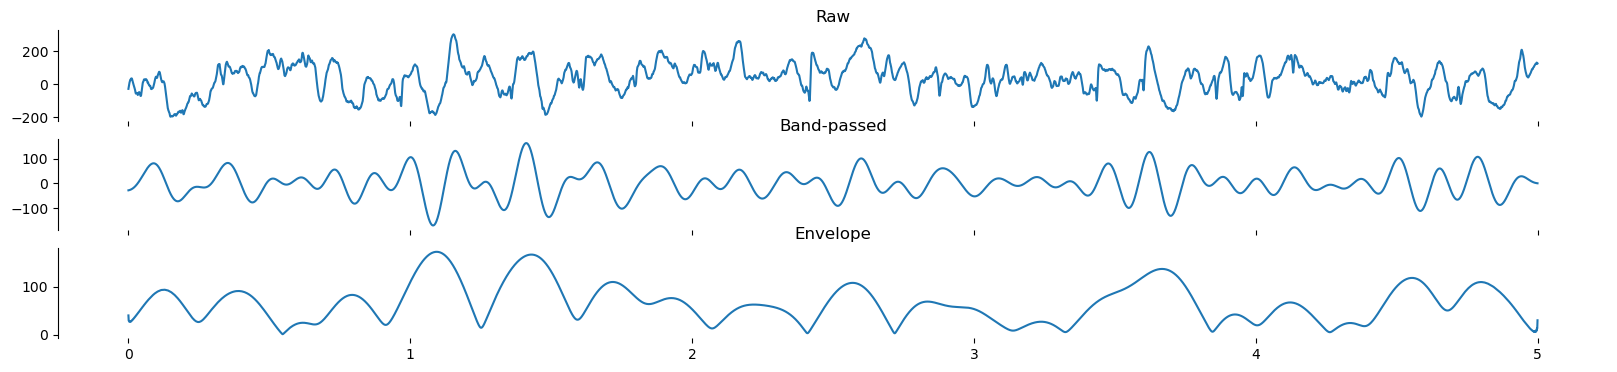

In [14]:
# What does eeg data actually look like?
plotsEEG(eeg[:,0],eeg_sr,s=5,duration=5,low=3,high=8)

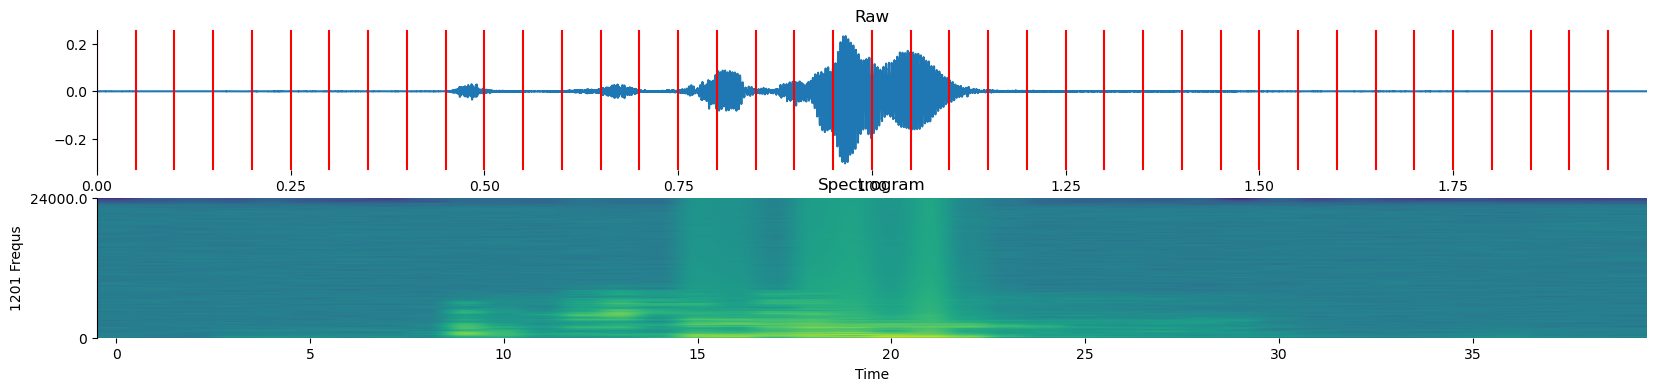

In [12]:
# Let's inspect the audio data
plotRawSpec(audio[:],audio_sr,s=6,duration=2,winLength=0.05)

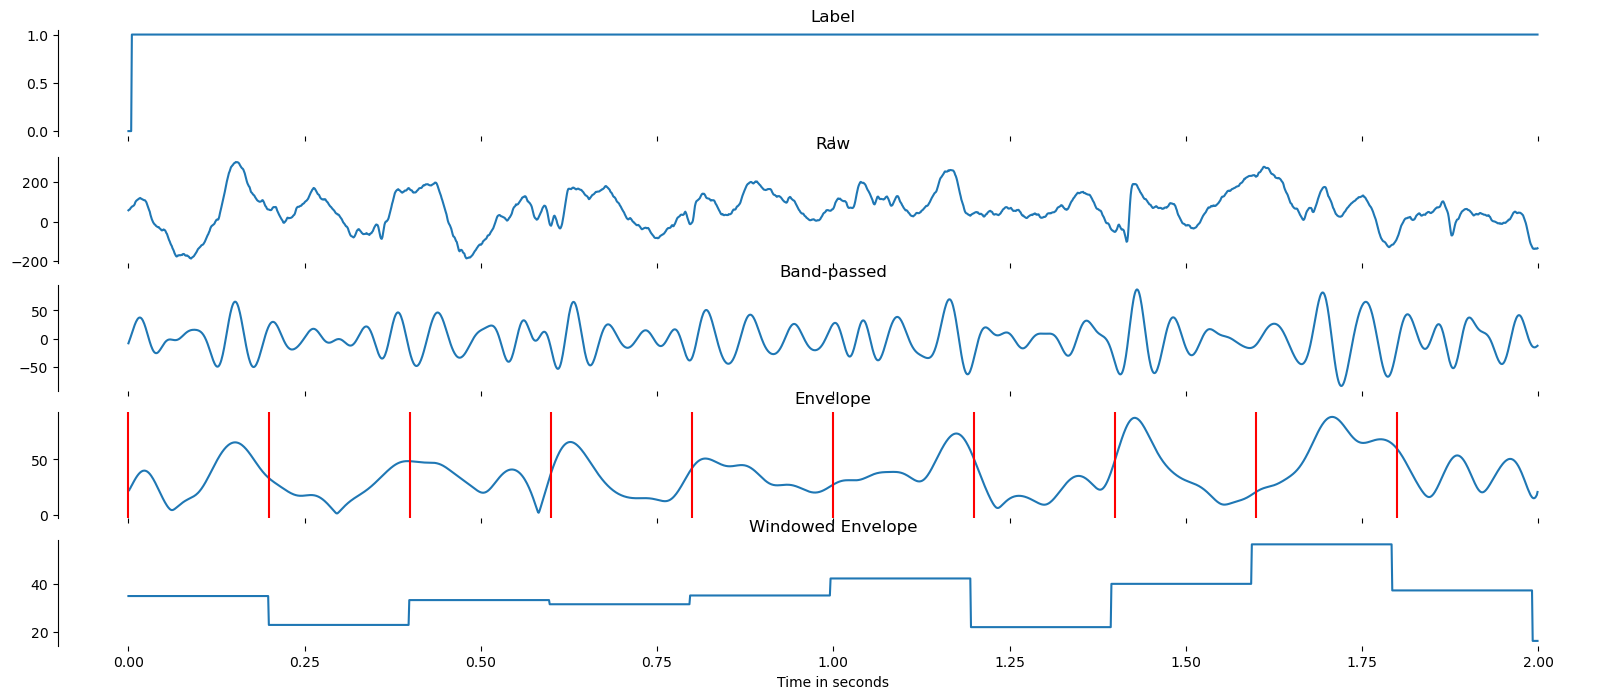

In [13]:
# Visualizing words and eeg together
plotsEEGFeatures(eeg[:,0],words,eeg_sr,s=6,duration=2,low=12,high=30,winL=0.2)

In [17]:
#Small helper function to speed up the hilbert transform by extending the length of data to the next power of 2
hilbert3 = lambda x: scipy.signal.hilbert(x, scipy.fftpack.next_fast_len(len(x)),axis=0)[:len(x)]

def extractHG(data, sr, windowLength=0.05, frameshift=0.01):
    """
    Window data and extract frequency-band envelope using the hilbert transform
    
    Parameters
    ----------
    data: array (samples, channels)
        EEG time series
    sr: int
        Sampling rate of the data
    windowLength: float
        Length of window (in seconds) in which spectrogram will be calculated
    frameshift: float
        Shift (in seconds) after which next window will be extracted
    Returns
    ----------
    feat: array (windows, channels)
        Frequency-band feature matrix
    """
    #Linear detrend
    data = scipy.signal.detrend(data,axis=0)
    #Number of windows
    numWindows = int(np.floor((data.shape[0]-windowLength*sr)/(frameshift*sr))+1)
    #Filter High-Gamma Band
    sos = scipy.signal.iirfilter(4, [70/(sr/2),170/(sr/2)],btype='bandpass',output='sos')
    data = scipy.signal.sosfiltfilt(sos,data,axis=0)
    #Attenuate first harmonic of line noise
    sos = scipy.signal.iirfilter(4, [98/(sr/2),102/(sr/2)],btype='bandstop',output='sos')
    data = scipy.signal.sosfiltfilt(sos,data,axis=0)
    #Attenuate second harmonic of line noise
    sos = scipy.signal.iirfilter(4, [148/(sr/2),152/(sr/2)],btype='bandstop',output='sos')
    data = scipy.signal.sosfiltfilt(sos,data,axis=0)
    #Create feature space
    data = np.abs(hilbert3(data))
    feat = np.zeros((numWindows,data.shape[1]))
    for win in range(numWindows):
        start= int(np.floor((win*frameshift)*sr))
        stop = int(np.floor(start+windowLength*sr))
        feat[win,:] = np.mean(data[start:stop,:],axis=0)
    return feat

def stackFeatures(features, modelOrder=4, stepSize=5):
    """
    Add temporal context to each window by stacking neighboring feature vectors
    
    Parameters
    ----------
    features: array (windows, channels)
        Feature time series
    modelOrder: int
        Number of temporal context to include prior to and after current window
    stepSize: float
        Number of temporal context to skip for each next context (to compensate for frameshift)
    Returns
    ----------
    featStacked: array (windows, feat*(2*modelOrder+1))
        Stacked feature matrix
    """
    featStacked=np.zeros((features.shape[0]-(2*modelOrder*stepSize),(2*modelOrder+1)*features.shape[1]))
    for fNum,i in enumerate(range(modelOrder*stepSize,features.shape[0]-modelOrder*stepSize)):
        ef=features[i-modelOrder*stepSize:i+modelOrder*stepSize+1:stepSize,:]
        featStacked[fNum,:]=ef.flatten() #Add 'F' if stacked the same as matlab
    return featStacked

def downsampleLabels(labels, sr, windowLength=0.05, frameshift=0.01):
    """
    Downsamples non-numerical data by using the mode
    
    Parameters
    ----------
    labels: array of str
        Label time series
    sr: int
        Sampling rate of the data
    windowLength: float
        Length of window (in seconds) in which mode will be used
    frameshift: float
        Shift (in seconds) after which next window will be extracted
    Returns
    ----------
    newLabels: array of str
        Downsampled labels
    """
    numWindows=int(np.floor((labels.shape[0]-windowLength*sr)/(frameshift*sr)))
    newLabels = np.empty(numWindows, dtype="S15")
    for w in range(numWindows):
        start = int(np.floor((w*frameshift)*sr))
        stop = int(np.floor(start+windowLength*sr))
        newLabels[w]=scipy.stats.mode(labels[start:stop])[0][0].encode("ascii", errors="ignore").decode()
    return newLabels

def extractMelSpecs(audio, sr, windowLength=0.05, frameshift=0.01):
    """
    Extract logarithmic mel-scaled spectrogram, traditionally used to compress audio spectrograms
    
    Parameters
    ----------
    audio: array
        Audio time series
    sr: int
        Sampling rate of the audio
    windowLength: float
        Length of window (in seconds) in which spectrogram will be calculated
    frameshift: float
        Shift (in seconds) after which next window will be extracted
    numFilter: int
        Number of triangular filters in the mel filterbank
    Returns
    ----------
    spectrogram: array (numWindows, numFilter)
        Logarithmic mel scaled spectrogram
    """
    numWindows=int(np.floor((audio.shape[0]-windowLength*sr)/(frameshift*sr)))
    win = scipy.hanning(np.floor(windowLength*sr + 1))[:-1]
    spectrogram = np.zeros((numWindows, int(np.floor(windowLength*sr / 2 + 1))),dtype='complex')
    for w in range(numWindows):
        start_audio = int(np.floor((w*frameshift)*sr))
        stop_audio = int(np.floor(start_audio+windowLength*sr))
        a = audio[start_audio:stop_audio]
        spec = np.fft.rfft(win*a)
        spectrogram[w,:] = spec
    mfb = mel.MelFilterBank(spectrogram.shape[1], 23, sr)
    spectrogram = np.abs(spectrogram)
    spectrogram = (mfb.toLogMels(spectrogram)).astype('float')
    return spectrogram

def nameVector(elecs, modelOrder=4):
    """
    Creates list of electrode names
    
    Parameters
    ----------
    elecs: array of str
        Original electrode names
    modelOrder: int
        Temporal context stacked prior and after current window
        Will be added as T-modelOrder, T-(modelOrder+1), ...,  T0, ..., T+modelOrder
        to the elctrode names
    Returns
    ----------
    names: array of str
        List of electrodes including contexts, will have size elecs.shape[0]*(2*modelOrder+1)
    """
    names = matlib.repmat(elecs.astype(np.dtype(('U', 10))),1,2 * modelOrder +1).T
    for i, off in enumerate(range(-modelOrder,modelOrder+1)):
        names[i,:] = [e[0] + 'T' + str(off) for e in elecs]
    return names.flatten()  #Add 'F' if stacked the same as matlab

In [22]:
# Putting it all together
winL = 0.05
frameshift = 0.01
modelOrder = 4
stepSize = 5
path_bids = r'./SingleWordProductionDutch-iBIDS'
path_output = r'./features'
participants = pd.read_csv(os.path.join(path_bids,'participants.tsv'), delimiter='\t')
for p_id, participant in enumerate(participants['participant_id']):

    #Load data
    io = NWBHDF5IO(os.path.join(path_bids,participant,'ieeg',f'{participant}_task-wordProduction_ieeg.nwb'), 'r')
    nwbfile = io.read()
    #sEEG
    eeg = nwbfile.acquisition['iEEG'].data[:]
    eeg_sr = 1024
    #audio
    audio = nwbfile.acquisition['Audio'].data[:]
    audio_sr = 48000
    #words (markers)
    words = nwbfile.acquisition['Stimulus'].data[:]
    words = np.array(words, dtype=str)
    io.close()
    #channels
    channels = pd.read_csv(os.path.join(path_bids,participant,'ieeg',f'{participant}_task-wordProduction_channels.tsv'), delimiter='\t')
    channels = np.array(channels['name'])

    #Extract HG features
    feat = extractHG(eeg,eeg_sr, windowLength=winL,frameshift=frameshift)

    #Stack features
    #feat = stackFeatures(feat,modelOrder=modelOrder,stepSize=stepSize)

    #Process Audio
    target_SR = 16000
    audio = scipy.signal.decimate(audio,int(audio_sr / target_SR))
    audio_sr = target_SR
    scaled = np.int16(audio/np.max(np.abs(audio)) * 32767)
    os.makedirs(os.path.join(path_output), exist_ok=True)
    scipy.io.wavfile.write(os.path.join(path_output,f'{participant}_orig_audio.wav'),audio_sr,scaled)   

    #Extract spectrogram
    melSpec = extractMelSpecs(scaled,audio_sr,windowLength=winL,frameshift=frameshift)

    #Align to EEG features
    words = downsampleLabels(words,eeg_sr,windowLength=winL,frameshift=frameshift)
    #words = words[modelOrder*stepSize:words.shape[0]-modelOrder*stepSize]
    #melSpec = melSpec[modelOrder*stepSize:melSpec.shape[0]-modelOrder*stepSize,:]
    #adjust length (differences might occur due to rounding in the number of windows)
    if melSpec.shape[0]!=feat.shape[0]:
        tLen = np.min([melSpec.shape[0],feat.shape[0]])
        melSpec = melSpec[:tLen,:]
        feat = feat[:tLen,:]

    #Create feature names by appending the temporal shift 
    feature_names = nameVector(channels[:,None], modelOrder=modelOrder)

    #Save everything
    np.save(os.path.join(path_output,f'{participant}_feat.npy'), feat)
    np.save(os.path.join(path_output,f'{participant}_procWords.npy'), words)
    np.save(os.path.join(path_output,f'{participant}_spec.npy'), melSpec)
    np.save(os.path.join(path_output,f'{participant}_feat_names.npy'), feature_names)

C:\Users\c.herff\AppData\Local\miniconda3\envs\multipurpose\Lib\site-packages\hdmf\spec\namespace.py:535: UserWarning: Ignoring cached namespace 'hdmf-common' version 1.5.1 because version 1.8.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
C:\Users\c.herff\AppData\Local\miniconda3\envs\multipurpose\Lib\site-packages\hdmf\spec\namespace.py:535: UserWarning: Ignoring cached namespace 'core' version 2.4.0 because version 2.8.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
C:\Users\c.herff\AppData\Local\miniconda3\envs\multipurpose\Lib\site-packages\hdmf\spec\namespace.py:535: UserWarning: Ignoring cached namespace 'hdmf-experimental' version 0.2.0 because version 0.5.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
C:\Users\c.herff\AppData\Local\Temp\ipykernel_66048\3144211713.py:117: DeprecationWarning: s

C:\Users\c.herff\AppData\Local\miniconda3\envs\multipurpose\Lib\site-packages\hdmf\spec\namespace.py:535: UserWarning: Ignoring cached namespace 'hdmf-common' version 1.5.1 because version 1.8.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
C:\Users\c.herff\AppData\Local\miniconda3\envs\multipurpose\Lib\site-packages\hdmf\spec\namespace.py:535: UserWarning: Ignoring cached namespace 'core' version 2.4.0 because version 2.8.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
C:\Users\c.herff\AppData\Local\miniconda3\envs\multipurpose\Lib\site-packages\hdmf\spec\namespace.py:535: UserWarning: Ignoring cached namespace 'hdmf-experimental' version 0.2.0 because version 0.5.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
C:\Users\c.herff\AppData\Local\Temp\ipykernel_66048\3144211713.py:117: DeprecationWarning: s

C:\Users\c.herff\AppData\Local\miniconda3\envs\multipurpose\Lib\site-packages\hdmf\spec\namespace.py:535: UserWarning: Ignoring cached namespace 'hdmf-common' version 1.5.1 because version 1.8.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
C:\Users\c.herff\AppData\Local\miniconda3\envs\multipurpose\Lib\site-packages\hdmf\spec\namespace.py:535: UserWarning: Ignoring cached namespace 'core' version 2.4.0 because version 2.8.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
C:\Users\c.herff\AppData\Local\miniconda3\envs\multipurpose\Lib\site-packages\hdmf\spec\namespace.py:535: UserWarning: Ignoring cached namespace 'hdmf-experimental' version 0.2.0 because version 0.5.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
C:\Users\c.herff\AppData\Local\Temp\ipykernel_66048\3144211713.py:117: DeprecationWarning: s